In [ ]:
!pip install catboost lightgbm

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from scipy.stats import rankdata
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from metric import precision_at_recall, recall_at_fpr, pr_curve

In [4]:
train = pd.read_csv('/content/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('/content/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('/content/events.csv', parse_dates=['event_ts'])

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          11091 non-null  object        
 1   cookie_created_at  11091 non-null  datetime64[ns]
 2   window_start_ts    11091 non-null  datetime64[ns]
 3   window_end_ts      11091 non-null  datetime64[ns]
 4   target             11091 non-null  int64         
dtypes: datetime64[ns](3), int64(1), object(1)
memory usage: 433.4+ KB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          4909 non-null   object        
 1   cookie_created_at  4909 non-null   datetime64[ns]
 2   window_start_ts    4909 non-null   datetime64[ns]
 3   window_end_ts      4909 non-null   datetime64[ns]
dtypes: datetime64[ns](3), object(1)
memory usage: 153.5+ KB


# **EDA**

In [7]:
print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean())
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0810567126498963


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


Видно, что в размеченных данных есть дисбаланс классов. Все-таки ботов гораздо меньше, чем не ботов, то есть нас, людей.

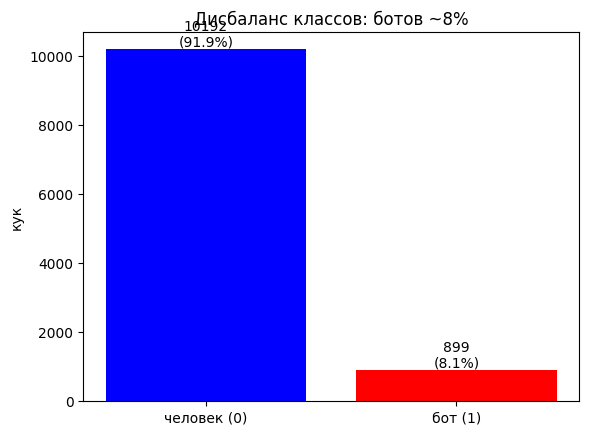

In [8]:
counts = train.target.value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(["человек (0)", "бот (1)"], counts.values, color=["blue", "red"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}\n({v / len(train):.1%})", ha="center", va="bottom")
ax.set_ylabel("кук")
ax.set_title("Дисбаланс классов: ботов ~8%")
plt.show()

In [9]:
print("train:", train.shape, "test:", test.shape)
print("Типы колонок:", train.dtypes)

train: (11091, 5) test: (4909, 4)
Типы колонок: cookie_id                    object
cookie_created_at    datetime64[ns]
window_start_ts      datetime64[ns]
window_end_ts        datetime64[ns]
target                        int64
dtype: object


Интересный тип данных datetime64 с точностью до наносекунд

Проверим длительность окон и расположение train/test во времени.

От этого будет зависеть стратегия валидации

In [10]:
for df, name in [(train, "train"), (test, "test")]:
    dur_days = (df.window_end_ts - df.window_start_ts).dt.total_seconds() / 86400
    print(f"{name}: длительность окна (дней) = {sorted(dur_days.unique())}, "
          f"окна с {df.window_start_ts.min().date()} по {df.window_start_ts.max().date()}")

daily = train.assign(day=train.window_start_ts.dt.date).groupby("day").target.agg(["size", "mean"])
print("Бот-рейт по дням train:", daily.round(3))

train: длительность окна (дней) = [np.float64(1.0)], окна с 2026-04-06 по 2026-04-19
test: длительность окна (дней) = [np.float64(1.0)], окна с 2026-04-20 по 2026-04-26
Бот-рейт по дням train:             size   mean
day                    
2026-04-06   772  0.088
2026-04-07   797  0.074
2026-04-08   834  0.084
2026-04-09   902  0.073
2026-04-10   912  0.090
2026-04-11   896  0.088
2026-04-12   817  0.082
2026-04-13   843  0.063
2026-04-14   826  0.085
2026-04-15   801  0.081
2026-04-16   740  0.081
2026-04-17   713  0.093
2026-04-18   606  0.086
2026-04-19   632  0.066


Окно наблюдения ровно 1 сутки

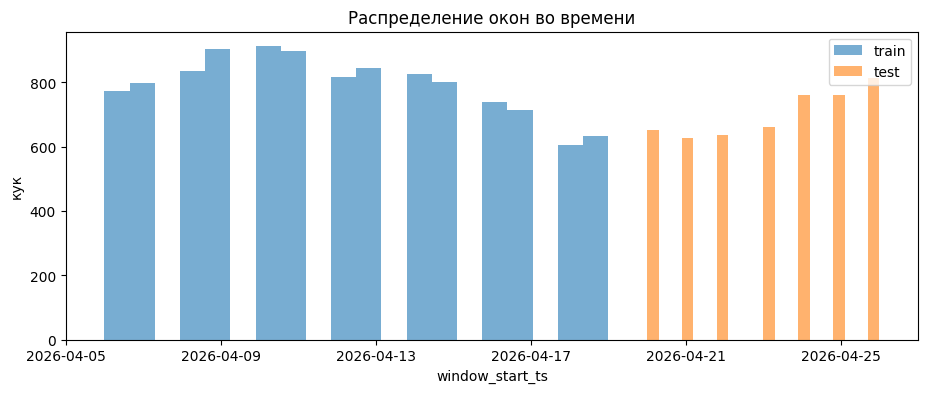

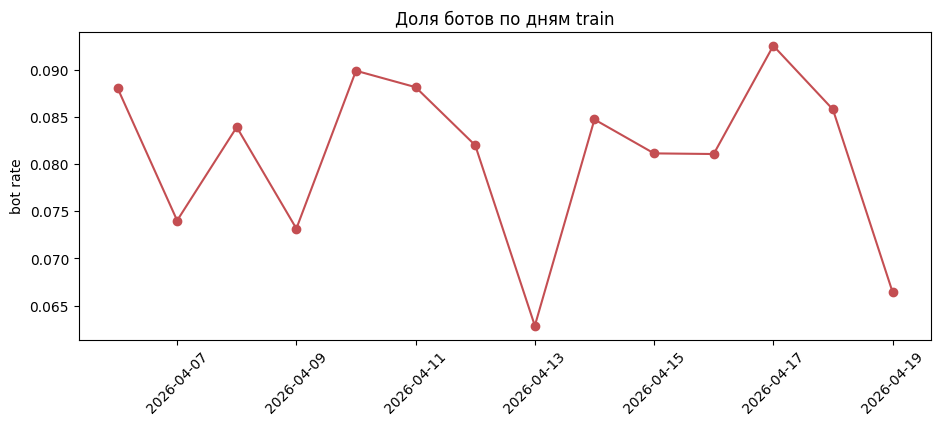

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(train.window_start_ts, bins=20, alpha=0.6, label="train")
ax.hist(test.window_start_ts, bins=20, alpha=0.6, label="test")
ax.set_xlabel("window_start_ts")
ax.set_ylabel("кук")
ax.set_title("Распределение окон во времени")
ax.legend()
plt.show()

daily = train.assign(day=train.window_start_ts.dt.date).groupby("day").target.mean()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily.index, daily.values, marker="o", color="#c44e52")
ax.set_ylabel("bot rate")
ax.set_title("Доля ботов по дням train")
plt.xticks(rotation=45)
plt.show()

Нужно предсказать будущее относительно train

Последние дни train чуть меньше по объёму

Бот-рейт по дням 0.063–0.093, без тренда и выбросов - дрейфа распределения метки нет, значит модель, обученная на всем train, должна переноситься на test без дообучения

Вообще возраст куки это насколько давно система знает этот браузер

Человек обычно пользуется сайтом давно и поэтому его кука была создана давно и есть какая-то история к началу окна

бот он же парсер стартует с новой куки. И кука у него молодая.

отнесемся к возрасту как к вероятностному признаку

Посмотрим на возраст кука, так как свежая кука может быть признаком автоматического трафика

то есть ищем сигнал на бота

In [12]:
for df, name in [(train, "train"), (test, "test")]:
    age = (df.window_start_ts - df.cookie_created_at).dt.total_seconds() / 86400
    print(f"{name}: возраст куки на начало окна, квантили .1/.5/.9 = "
          f"{age.quantile([.1, .5, .9]).round(1).tolist()} дней")

age_tr = (train.window_start_ts - train.cookie_created_at).dt.total_seconds() / 86400
print("Медианный возраст по классам:", age_tr.groupby(train.target).median().round(1))
print("Доля куки, рождённых < 1 дня до окна, по классам:",
      age_tr.lt(1).groupby(train.target).mean().round(3))

train: возраст куки на начало окна, квантили .1/.5/.9 = [0.8, 59.8, 161.6] дней
test: возраст куки на начало окна, квантили .1/.5/.9 = [0.8, 58.6, 164.4] дней
Медианный возраст по классам: target
0    61.8
1    19.0
dtype: float64
Доля куки, рождённых < 1 дня до окна, по классам: target
0    0.104
1    0.259
dtype: float64


Распределения train и test идентичны. Это ещё одно подтверждение отсутствия временного дрейфа

Медианный возраст различается в 3 раза: 61.8 дней у людей против 19.0 дней у ботов.

Доля «однодневок» у ботов в 2.5 раза выше (25.9% против 10.4%).
это паттерн, так как
парсеры часто генерируют новые сессии/куки при каждом запуске или после бана ;)

90-й перцентиль ~162 дня, значит распределение сильно скошено вправо. Нужен логарифм

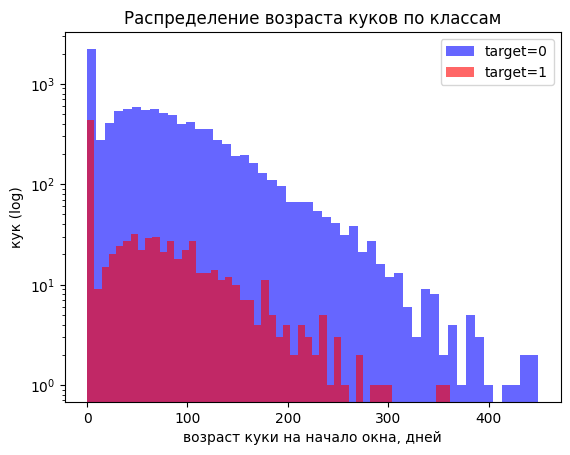

In [13]:
age = (train.window_start_ts - train.cookie_created_at).dt.total_seconds() / 86400

fig, ax = plt.subplots()
for cls, color in [(0, "blue"), (1, "red")]:
    ax.hist(age[train.target == cls], bins=50, alpha=0.6, color=color, label=f"target={cls}")
ax.set_yscale("log")
ax.set_xlabel("возраст куки на начало окна, дней")
ax.set_ylabel("кук (log)")
ax.set_title("Распределение возраста куков по классам")
ax.legend()
plt.show()

Посмотрим на данные с точки зрения задвоенности, так как данные могли быть собраны с ошибкой

In [14]:
assert train.cookie_id.is_unique and test.cookie_id.is_unique, "дубли cookie_id внутри файлов"
assert not (set(train.cookie_id) & set(test.cookie_id)), "пересечение train/test"
print("cookie_id уникальны, пересечений нет")

cookie_id уникальны, пересечений нет


Теперь посмотрим на события

In [15]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [16]:
print("events:", events.shape)
print("Пропуски:", events.isna().mean().sort_values(ascending=False).head(10))

events: (328905, 14)
Пропуски: search_query     0.694739
search_page      0.694739
pointer_x        0.669996
pointer_y        0.669996
seller_type      0.406966
item_id          0.348420
item_category    0.100090
item_location    0.072340
user_agent       0.000000
platform         0.000000
dtype: float64


Вот здесь проблема. пропуски есть и их много

в нашем случае, получается, что пропуски структурные, можно сказать это тоже признак

Две парные группы пропусков с одинаковыми долями:
search_query = search_page = 69.5% получается, заполняются только для поисковых событий всегда вместе

pointer_x = pointer_y = 67.0% курсор логируется только там, где он физически есть (web/desktop), всегда парой.


Условные поля объявлений: item_id пуст в 34.8% (нет объявления у поисковых/служебных событий), при этом item_category пуст лишь в 10%, а item_location в 7.2% значит категория/локация встречаются и без item_id например, фильтры поиска или страница продавца - паттерн пропусков неоднородный, каждый несёт информацию.

seller_type пуст в 40.7% значит относится только к событиям, связанным с объявлением/продавцом.

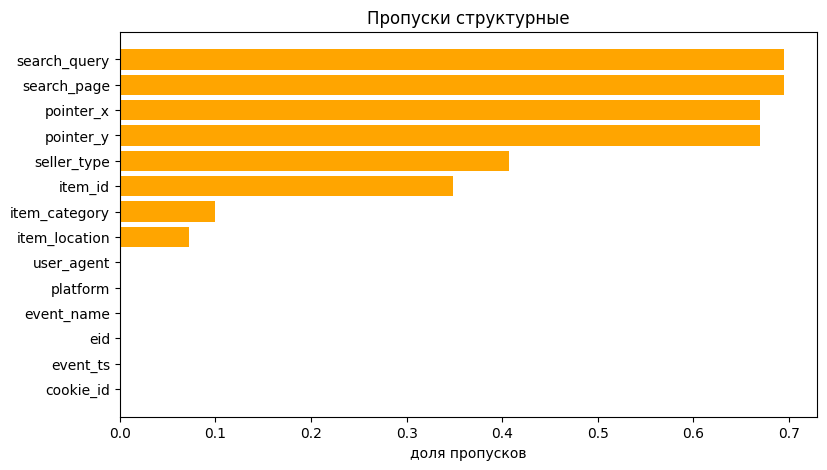

In [17]:
miss = events.isna().mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(miss.index, miss.values, color="orange")
ax.set_xlabel("доля пропусков")
ax.set_title("Пропуски структурные")
plt.show()

Посмотрим на каталог событий и платформ, чтобы зафиксировать словарь поведения и технические артефакты полей

In [18]:
print("Типы событий:", events.event_name.value_counts())
print()
print("Платформы:", events.platform.value_counts())
print()
print("Полных дублей строк:", int(events.duplicated().sum()))

Типы событий: event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64

Платформы: platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64

Полных дублей строк: 4863


Каталог событий 10 типов

Ядро поведения: item_view 36.7% + search_results_view 30.5% = ~2/3 всех событий

photo_swipe 11.1%, favorite_add 5.8%, seller_page_view 5.3% — глубина интереса

Человеческие сигналы редкие: контактные события суммарно ~6%, login 1.9%


в платформах полный хаос

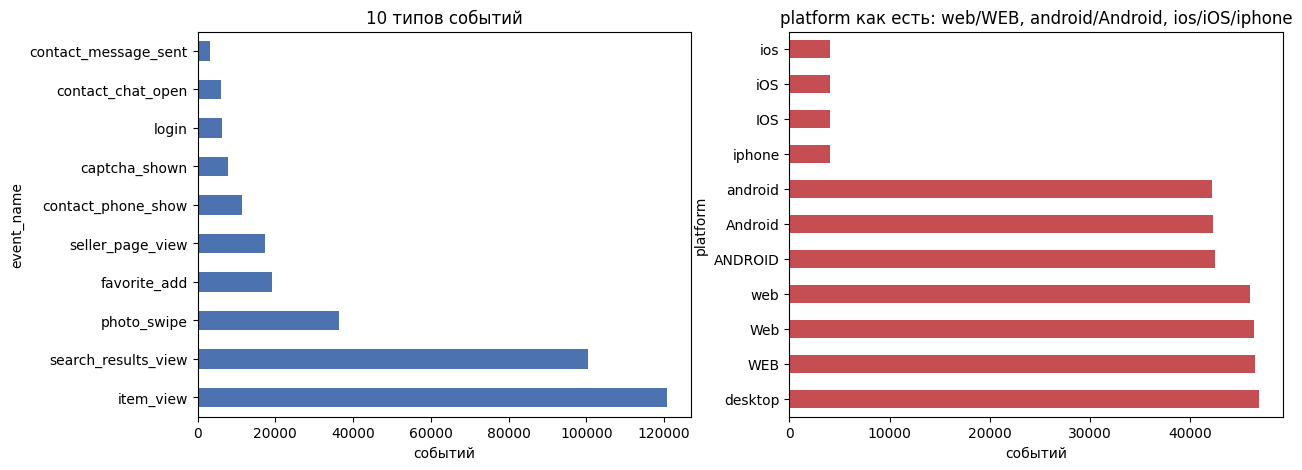

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
events.event_name.value_counts().plot.barh(ax=axes[0], color="#4c72b0")
axes[0].set_title("10 типов событий")
axes[0].set_xlabel("событий")

events.platform.value_counts().plot.barh(ax=axes[1], color="#c44e52")
axes[1].set_title("platform как есть: web/WEB, android/Android, ios/iOS/iphone")
axes[1].set_xlabel("событий")
plt.show()

Посмотрим на найденные дубли

доля дублей: 0.0148
типы дублирующихся событий: event_name
item_view              1827
search_results_view    1473
photo_swipe             555
favorite_add            310
seller_page_view        223
Name: count, dtype: int64
доля дублей по классам:           mean  median  max
target                     
0       0.0134     0.0  0.5
1       0.0136     0.0  0.2


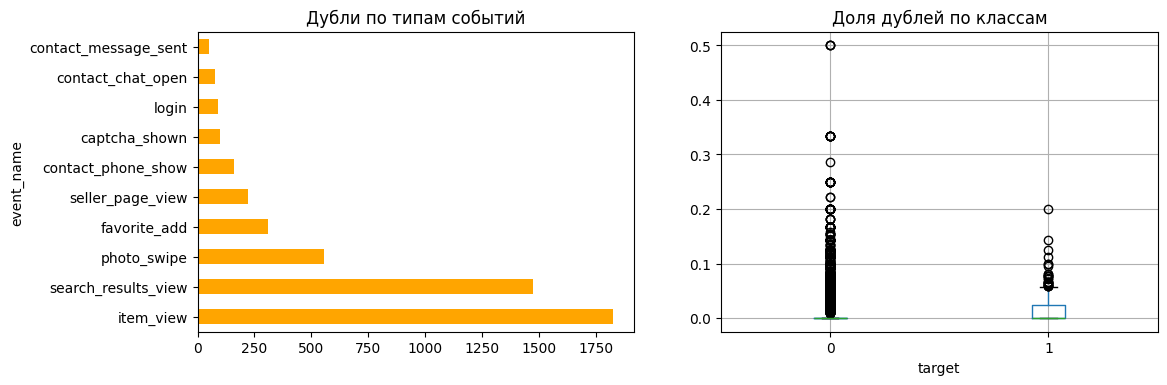

In [20]:
dup = events.duplicated()
print("доля дублей:", round(dup.mean(), 4))
print("типы дублирующихся событий:", events[dup].event_name.value_counts().head())

dup_share = dup.groupby(events.cookie_id).mean().rename("dup_share")
chk = dup_share.reset_index().merge(train[["cookie_id", "target"]], on="cookie_id")
print("доля дублей по классам:",
      chk.groupby("target").dup_share.agg(["mean", "median", "max"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
events[dup].event_name.value_counts().plot.barh(ax=axes[0], color="orange")
axes[0].set_title("Дубли по типам событий")
chk.boxplot(column="dup_share", by="target", ax=axes[1])
axes[1].set_title("Доля дублей по классам")
plt.suptitle("")
plt.show()

Дубли живут только в смотрительных событиях: item_view (1827), search_results_view (1473), photo_swipe (555), favorite_add (310), seller_page_view (223).

По классам разделения нет: mean 0.0134 (люди) vs 0.0136 (боты), медианы 0 у обоих. Боксплот подтверждает, что масса у нуля в обоих классах, редкие выбросы есть и там и там

Полные дубли удаляем до построения любых признаков, так как они задваивают счётчики и искажают статистики, а информативности не несут.

Удаляем дубли по всем колонкам (включая event_ts), т.к. частичные дубли могут быть легитимными параллельными действиями

Позволю сделать себе это прямо в EDA

In [21]:
events = events.drop_duplicates()

In [22]:
events.duplicated().sum()

np.int64(0)

Посмотрим на покрытие кук, чтобы понять, у скольких кук вообще есть события в окне и сколько событий на куку - от этого зависит стратегия заполнения пропусков.

In [23]:
meta = pd.concat([train, test], ignore_index=True)
ev = events.merge(meta[["cookie_id", "window_start_ts", "window_end_ts"]],
                  on="cookie_id", how="inner")
in_win = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]
print(f"событий внутри окон: {len(in_win)} из {len(events)} ({len(in_win)/len(events):.1%})")

n_ev = in_win.groupby("cookie_id").size()
print("событий на куку:", n_ev.describe().round(1))

has_ev = set(in_win.cookie_id)
for name, df in [("train", train), ("test", test)]:
    print(f"{name}: доля кук с событиями = {df.cookie_id.isin(has_ev).mean():.1%}")

событий внутри окон: 283833 из 324042 (87.6%)
событий на куку: count    16000.0
mean        17.7
std         17.7
min          1.0
25%          6.0
50%         12.0
75%         23.0
max        187.0
dtype: float64
train: доля кук с событиями = 100.0%
test: доля кук с событиями = 100.0%


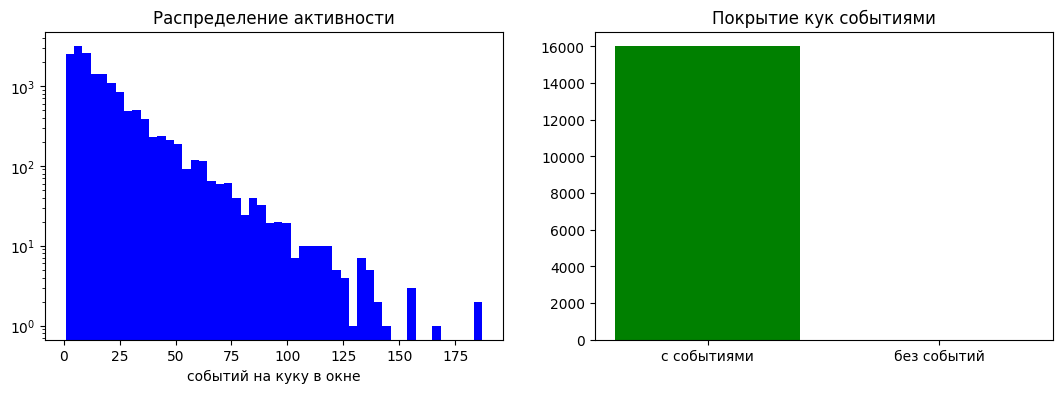

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(n_ev, bins=50, color="blue")
axes[0].set_yscale("log")
axes[0].set_xlabel("событий на куку в окне")
axes[0].set_title("Распределение активности")
axes[1].bar(["с событиями", "без событий"],
            [len(has_ev), meta.cookie_id.nunique() - len(has_ev)],
            color=["green", "red"])
axes[1].set_title("Покрытие кук событиями")
plt.show()

87.6% событий лежат внутри окон (283 833 из 324 042 после удаления дублей)

12.4% (~40 тыс.) - вне окон. Почти наверняка это история до начала окна, но это надо проверить явно: события после window_end использовать запрещено из-за утечки будущего, события до window_start легальны, так как известны на момент решения.

Покрытие 100%. у всех 16 000 кук train + test есть хотя бы одно событие в окне.

Распределение активности: медиана 12 событий, Q3 = 23, хвост до 187; mean ≈ std ≈ 17.7 похоже на экспоненциальное/логнормальное. Хвост сверхактивных - это парсеры; деревьям такие признаки будут полезны без трансформаций


min = 1 есть куки с единственным событием значит у них статистики не определены. не будем заполнять их нулями, а то еще искусственно бота сделаем

In [25]:
mask_in = (ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)
out = ev[~mask_in]
share_before = (out.event_ts < out.window_start_ts).mean()
print(f"вне окна: {len(out)} событий; до начала окна: {share_before:.1%}; после конца: {1 - share_before:.1%}")

вне окна: 40209 событий; до начала окна: 0.0%; после конца: 100.0%


истории до окна в данных не существует вовсе. событийная лента каждой куки начинается с её окна и продолжается хвостом в будущее.

Теперь проверим до построения полного пайплайна, что гипотезы (регулярность, курсор, капча, объём) реально разделяют классы.

In [26]:
tr_ev = in_win[in_win.cookie_id.isin(set(train.cookie_id))].sort_values(["cookie_id", "event_ts"])
gid = tr_ev.cookie_id
gap = tr_ev.groupby("cookie_id").event_ts.diff().dt.total_seconds().dropna()
gap_gid = gid.reindex(gap.index)
gap_cv = (gap.groupby(gap_gid).std() / (gap.groupby(gap_gid).mean() + 1e-9)).rename("gap_cv")

quick = pd.concat([
    gid.groupby(gid).size().rename("n_events"),
    (tr_ev.pointer_x.isna() | tr_ev.pointer_y.isna()).groupby(gid).mean().rename("ptr_missing_share"),
    tr_ev.event_name.eq("captcha_shown").groupby(gid).max().rename("has_captcha"),
    tr_ev.event_name.eq("login").groupby(gid).max().rename("has_login"),
    gap_cv,
], axis=1).reset_index().merge(train[["cookie_id", "target"]], on="cookie_id")

num_cols = ["n_events", "ptr_missing_share", "has_captcha", "has_login", "gap_cv"]
summary = quick.groupby("target")[num_cols].mean().round(3)
print(summary)



        n_events  ptr_missing_share  has_captcha  has_login  gap_cv
target                                                             
0         16.619              0.646          0.0      0.269   2.016
1         29.038              0.735          0.0      0.192   2.646


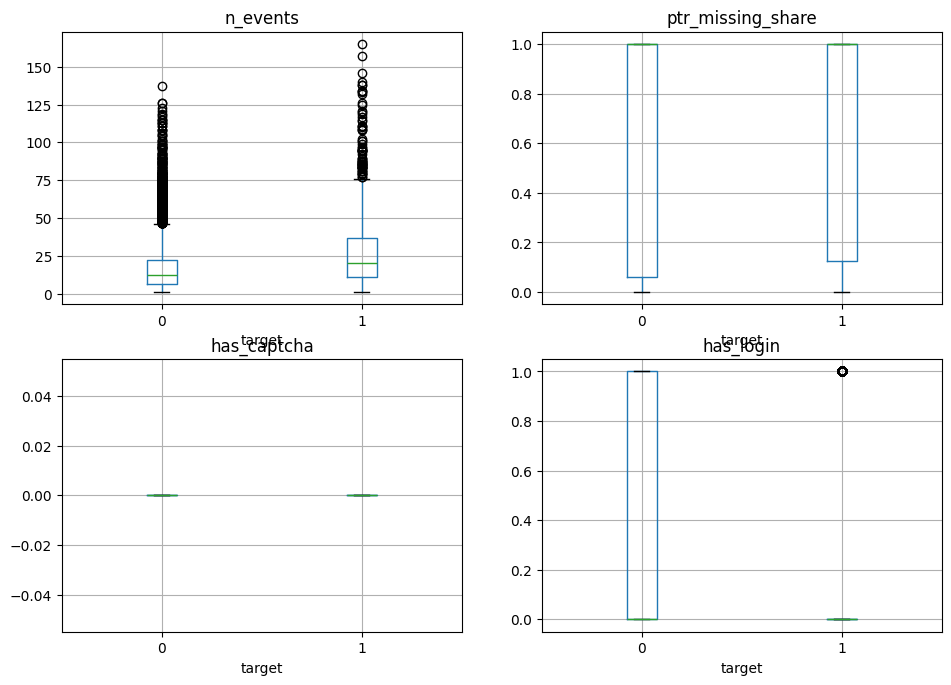

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), num_cols[:4]):
    quick.boxplot(column=col, by="target", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("target")
plt.suptitle("")
plt.show()

Боты в ~1.75 раза активнее — сильный признак

У ботов чаще нет курсора

Люди чаще входят в аккаунт

has_captcha = 0 в обоих классах внутри окна. признак бесполезен, выкидываем

Есть предположение, что у человека и бота разное поведение. Посмотрим...

In [28]:
bot_id = quick.query("target == 1").n_events.idxmax() and \
         quick.query("target == 1").sort_values("n_events", ascending=False).cookie_id.iloc[0]
hum_id = quick.query("target == 0 and has_login == 1").sort_values("n_events", ascending=False).cookie_id.iloc[0]
cols = ["event_ts", "event_name", "platform", "search_page", "pointer_x"]
for cid, label in [(bot_id, "БОТ"), (hum_id, "ЧЕЛОВЕК")]:
    print(f"{label} {cid}")
    print(in_win[in_win.cookie_id == cid][cols].head(12).to_string(index=False))

БОТ ck_71bf885006274d6a
           event_ts          event_name platform  search_page  pointer_x
2026-04-10 07:59:18    seller_page_view      WEB          NaN        NaN
2026-04-10 05:47:14           item_view      WEB          NaN        NaN
2026-04-10 10:15:29           item_view      WEB          NaN        NaN
2026-04-10 05:47:07    seller_page_view  desktop          NaN        NaN
2026-04-10 05:48:09           item_view      WEB          NaN        NaN
2026-04-10 07:58:23           item_view      WEB          NaN        NaN
2026-04-10 05:47:00 search_results_view      Web          5.0        NaN
2026-04-10 01:21:07           item_view      Web          NaN        NaN
2026-04-10 10:18:55 search_results_view      web          8.0        NaN
2026-04-10 01:21:59           item_view      Web          NaN        NaN
2026-04-10 05:48:19           item_view      WEB          NaN        NaN
2026-04-10 10:17:34           item_view  desktop          NaN        NaN
ЧЕЛОВЕК ck_352bfd2d163c99da

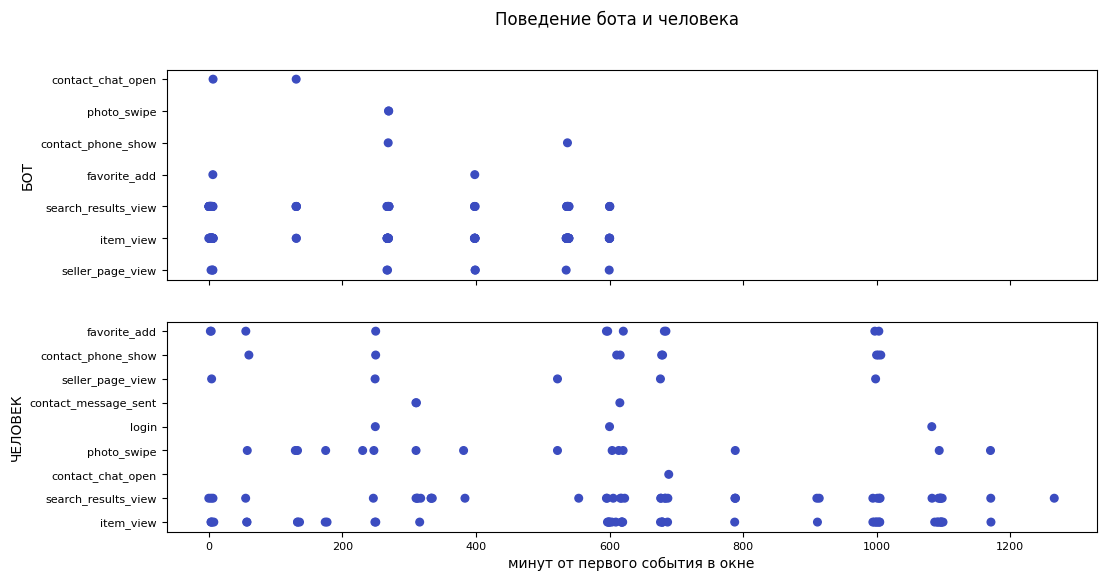

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (cid, label) in zip(axes, [(bot_id, "БОТ"), (hum_id, "ЧЕЛОВЕК")]):
    d = in_win[in_win.cookie_id == cid].copy()
    d["t_min"] = (d.event_ts - d.event_ts.min()).dt.total_seconds() / 60
    ax.scatter(d.t_min, d.event_name, s=30,
               c=d.pointer_x.notna(), cmap="coolwarm", vmin=0, vmax=1)
    ax.set_ylabel(label)
    ax.tick_params(labelsize=8)
axes[1].set_xlabel("минут от первого события в окне")
fig.suptitle("Поведение бота и человека")
plt.show()

Бот (ck_71bf885006274d6a):
Работает неестественно: всплески в 01:21, 05:47, 07:58, 10:15 периодичность ~2.5 часа, внутри всплеска интервалы 7–15 секунд. Короче это расписание парсера


Человек (ck_352bfd2d163c99da):
Сессии внутри дня (12:13–13:38, 18:51–20:27), рваный ритм, много photo_swipe, есть login.

# Feature engineering

фиксируем все константы в одном месте и нормализуем технические поля один раз

In [30]:
RS = 42
EPS = 1e-9
N_DIR_BINS = 8
UA_MOBILE_PATTERN = r"android|iphone|ipad|mobile"
UA_BOT_PATTERN = r"python|requests|scrapy|selenium|headless|curl|wget|bot|crawler|parser"
MOBILE_PLATFORMS = ("android", "ios")
EVENT_NAMES = (
    "item_view", "search_results_view", "photo_swipe", "favorite_add",
    "seller_page_view", "contact_phone_show", "captcha_shown",
    "login", "contact_chat_open", "contact_message_sent",
)

ev = in_win.copy()
ev = ev.sort_values(["cookie_id", "event_ts"], kind="stable").reset_index(drop=True)

ev["platform_norm"] = ev["platform"].str.lower().replace({"iphone": "ios"})
ua = ev["user_agent"].str.lower()
ev["ua_mobile"] = ua.str.contains(UA_MOBILE_PATTERN, regex=True, na=False)
ev["ua_plat_mismatch"] = ev["ua_mobile"] != ev["platform_norm"].isin(MOBILE_PLATFORMS)
ev["ua_bot"] = ua.str.contains(UA_BOT_PATTERN, regex=True, na=False)

g = ev.groupby("cookie_id")
F = pd.DataFrame(index=pd.Index(ev["cookie_id"].unique(), name="cookie_id"))

neg = (g["event_ts"].diff().dropna() < pd.Timedelta(0)).sum()
print("событий:", len(ev), "| кук:", len(F), "| отрицательных gap'ов:", int(neg))

событий: 283833 | кук: 16000 | отрицательных gap'ов: 0


n_events - главный объёмный сигнал доли типов устойчивее счётчиков к длине сессии
has_captcha сознательно не добавляем

In [31]:
counts = (
    ev.pivot_table(index="cookie_id", columns="event_name", values="event_ts",
                   aggfunc="count", fill_value=0)
      .reindex(columns=list(EVENT_NAMES), fill_value=0)
)
counts.columns = [f"ev_{c}" for c in counts.columns]
shares = counts.div(counts.sum(axis=1).replace(0, 1), axis=0)
shares.columns = [c.replace("ev_", "shr_", 1) for c in shares.columns]

F["n_events"] = g.size()
F = F.join(counts).join(shares)
F["contact_rate"] = (F["ev_contact_phone_show"] + F["ev_contact_chat_open"]
                     + F["ev_contact_message_sent"]) / F["n_events"]
F["has_login"] = (F["ev_login"] > 0).astype(int)
print("Shape", F.shape)

Shape (16000, 23)


Здесь работаем с регулярностью, вспышечностью, суточный профиль

Боты работают неестественно, пачки мгновенных событий (zero_gap_share) через паузы (long_pause_share, n_bursts), периодичность расписания ловим через burst_interval_cv; gap_cv оставляем с тем направлением, которое выучит модель.

In [32]:
dur = g["event_ts"].agg(["min", "max"])
F["duration_sec"] = (dur["max"] - dur["min"]).dt.total_seconds()
F["events_per_hour"] = F["n_events"] / (F["duration_sec"] / 3600.0 + EPS)

gap = g["event_ts"].diff().dt.total_seconds().dropna()
gap_gid = ev["cookie_id"].reindex(gap.index)
F = F.join(gap.groupby(gap_gid).agg(["mean", "std", "median", "min", "max"]).add_prefix("gap_"))
F["gap_cv"] = F["gap_std"] / (F["gap_mean"] + EPS)
F["zero_gap_share"] = gap.lt(1.0).groupby(gap_gid).mean()
F["long_pause_share"] = gap.gt(60.0).groupby(gap_gid).mean()
F["gap_autocorr"] = gap.groupby(gap_gid).apply(
    lambda s: s.autocorr(lag=1) if len(s) > 3 else np.nan)

long_gaps = gap[gap > 60.0]
lg_gid = gap_gid.reindex(long_gaps.index)
F["n_bursts"] = (long_gaps.groupby(lg_gid).size() + 1).reindex(F.index).fillna(1.0)
F["burst_interval_cv"] = (long_gaps.groupby(lg_gid).std() /
                          (long_gaps.groupby(lg_gid).mean() + EPS))

hrs = ev.assign(hour=ev["event_ts"].dt.hour)
F["night_share"] = hrs["hour"].between(0, 5).groupby(hrs["cookie_id"]).mean()
hc = hrs.groupby(["cookie_id", "hour"]).size()
p = hc / hc.groupby(level=0).transform("sum")
F["hour_entropy"] = -(p * np.log(p + EPS)).groupby(level=0).sum()
print("Shape:", F.shape, "| NaN в gap_cv (куки с 1 событием):", int(F["gap_cv"].isna().sum()))

Shape: (16000, 38) | NaN в gap_cv (куки с 1 событием): 951


повторы, переходы, листание, шаблонность переходов и монотонное листание выдачи - сигнал парсера

In [33]:
prev = g["event_name"].shift()
F["repeat_share"] = ev["event_name"].eq(prev).groupby(ev["cookie_id"]).mean()

tr = (prev + ">" + ev["event_name"]).dropna()
tr_gid = ev["cookie_id"].reindex(tr.index)
F["n_transitions"] = tr.groupby(tr_gid).nunique()
cnt = tr.groupby([tr_gid, tr]).size()
F["trans_top1_share"] = (cnt / cnt.groupby(level=0).transform("sum")).groupby(level=0).max()

sp = ev.loc[ev["event_name"] == "search_results_view", ["cookie_id", "search_page"]].copy()
sp["page"] = pd.to_numeric(sp["search_page"], errors="coerce")
dpg = sp.groupby("cookie_id")["page"].diff().dropna()
F["page_increase_share"] = dpg.gt(0).groupby(sp["cookie_id"].reindex(dpg.index)).mean()
F["max_search_page"] = sp.groupby("cookie_id")["page"].max()
print("Shape:", F.shape)

Shape: (16000, 43)


парсер смотрит много объявлений при узких запросах; отношения (views_per_item, items_per_query) ловят это лучше сырых счётчиков.

In [34]:
div_cols = ["item_id", "item_category", "item_location", "seller_type", "search_query", "search_page"]
F = F.join(g[div_cols].nunique().add_prefix("nuniq_"))
F["views_per_item"] = F["ev_item_view"] / (F["nuniq_item_id"] + EPS)
F["items_per_query"] = F["nuniq_item_id"] / (F["nuniq_search_query"] + EPS)
print("Shape:", F.shape)

Shape: (16000, 51)


на мобильных курсора нет, поэтому главный признак - ptr_missing_share_web (пропуск там, где курсор обязан быть: web/desktop); плюс траекторные статистики для тех, у кого курсор есть.

In [35]:
ptr = ev[["cookie_id", "pointer_x", "pointer_y"]]
F["ptr_missing_share"] = (ptr["pointer_x"].isna() | ptr["pointer_y"].isna()).groupby(ptr["cookie_id"]).mean()

web_mask = ev["platform_norm"].isin(["web", "desktop"])
ptr_miss_web = ev.loc[web_mask, "pointer_x"].isna() | ev.loc[web_mask, "pointer_y"].isna()
F["ptr_missing_share_web"] = ptr_miss_web.groupby(ev.loc[web_mask, "cookie_id"]).mean()

d = ptr.groupby("cookie_id")[["pointer_x", "pointer_y"]].diff()
dist = np.hypot(d["pointer_x"], d["pointer_y"]).dropna()
d_gid = ptr["cookie_id"].reindex(dist.index)
F["ptr_path_len"] = dist.groupby(d_gid).sum()
F["ptr_move_mean"] = dist.groupby(d_gid).mean()
F["ptr_move_zero_share"] = dist.eq(0).groupby(d_gid).mean()

ang = np.arctan2(d["pointer_y"], d["pointer_x"])
sector = (np.floor((ang + np.pi) / (2 * np.pi) * N_DIR_BINS) % N_DIR_BINS).dropna()
s_gid = ptr["cookie_id"].reindex(sector.index)
sc = sector.groupby([s_gid, sector]).size()
p = sc / sc.groupby(level=0).transform("sum")
F["ptr_dir_entropy"] = -(p * np.log(p + EPS)).groupby(level=0).sum()

first = ptr.groupby("cookie_id").first()
last = ptr.groupby("cookie_id").last()
F["ptr_straightness"] = (np.hypot(last["pointer_x"] - first["pointer_x"],
                                  last["pointer_y"] - first["pointer_y"])
                         / (F["ptr_path_len"] + EPS))
print("Shape:", F.shape)

Shape: (16000, 58)


микс платформ и смены платформы внутри куки - техническая аномалия; возраст куки - сильный априорный сигнал, подаём в трёх видах для разных моделей.

In [36]:
plat = ev.groupby(["cookie_id", "platform_norm"]).size().unstack(fill_value=0)
F = F.join(plat.div(plat.sum(axis=1), axis=0).add_prefix("plat_"))
F["ua_plat_mismatch_share"] = g["ua_plat_mismatch"].mean()
F["ua_bot_share"] = g["ua_bot"].mean()
F["nuniq_user_agent"] = g["user_agent"].nunique()
F["n_platforms"] = g["platform_norm"].nunique()

prev_plat = g["platform_norm"].shift()
F["platform_switch_share"] = (ev["platform_norm"].ne(prev_plat)
                              .where(prev_plat.notna())
                              .groupby(ev["cookie_id"]).mean())

ck = meta.drop_duplicates("cookie_id").set_index("cookie_id")
age = (ck["window_start_ts"] - ck["cookie_created_at"]).dt.total_seconds() / 86400.0
F["cookie_age_days"] = age
F["cookie_age_log"] = np.log1p(age.clip(lower=0))
F["is_fresh_1d"] = age.lt(1).astype(int)
F["is_fresh_7d"] = age.lt(7).astype(int)
print("Shape:", F.shape)

Shape: (16000, 71)


приводим к полным 16 000 кук (куки без событий станут NaN/0). NaN не зануляем для деревьев

In [37]:
cookie_index = pd.Index(meta["cookie_id"].unique(), name="cookie_id")
F = F.reindex(cookie_index)
print("колонок с NaN:", int(F.isna().any().sum()),
      "| строк с NaN:", int(F.isna().any(axis=1).sum()))
print(F.isna().mean().sort_values(ascending=False).head(6).round(4))

F_filled = F.replace([np.inf, -np.inf], np.nan).fillna(0.0)
print("Shape: матрица", F_filled.shape)

колонок с NaN: 21 | строк с NaN: 11970
ptr_path_len             0.6452
ptr_dir_entropy          0.6452
ptr_move_mean            0.6452
ptr_straightness         0.6452
ptr_move_zero_share      0.6452
ptr_missing_share_web    0.4638
dtype: float64
Shape: матрица (16000, 71)


/tmp/ipykernel_1083/3751525579.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  F_filled = F.replace([np.inf, -np.inf], np.nan).fillna(0.0)


аномальность и кластерная структура поведения по всем данным (train+test) без target. трансдуктивный подход, добавляет информации о редкости паттерна.

In [38]:
Xs = StandardScaler().fit_transform(F_filled.to_numpy(np.float32))
iso = IsolationForest(n_estimators=300, random_state=RS).fit(Xs)
F["iso_score"] = -iso.score_samples(Xs)

km = KMeans(n_clusters=16, n_init=10, random_state=RS).fit(Xs)
F["km_dist"] = km.transform(Xs).min(axis=1)
F = F.join(pd.get_dummies(pd.Series(km.labels_, index=F.index, name="cluster"),
                          prefix="cl", dtype=int))
print("Shape: финальная матрица", F.shape)

Shape: финальная матрица (16000, 89)


рискну и применю в этой задаче NLP.

TF-IDF по 1–3-граммам событий + SVD дают модели семантику всей последовательности, а не только агрегаты

In [39]:
seq = g["event_name"].agg(" ".join).reindex(cookie_index, fill_value="")
Xseq = TfidfVectorizer(ngram_range=(1, 3), min_df=5, sublinear_tf=True).fit_transform(seq)
emb = TruncatedSVD(n_components=8, random_state=RS).fit_transform(Xseq)
F = F.join(pd.DataFrame(emb, index=cookie_index,
                        columns=[f"seq_svd_{i}" for i in range(emb.shape[1])]))
print("Shape: матрица с эмбеддингами", F.shape)

Shape: матрица с эмбеддингами (16000, 97)


Убедимся, что признаки разделяют классы

In [40]:
chk = F.reset_index().merge(train[["cookie_id", "target"]], on="cookie_id")
chk_cols = ["n_events", "gap_cv", "zero_gap_share", "n_bursts",
            "ptr_missing_share_web", "cookie_age_days", "is_fresh_1d", "has_login"]
print(chk.groupby("target")[chk_cols].mean().round(3))

        n_events  gap_cv  zero_gap_share  n_bursts  ptr_missing_share_web  \
target                                                                      
0         16.619   2.016           0.007     7.575                  0.324   
1         29.038   2.646           0.002     5.739                  0.594   

        cookie_age_days  is_fresh_1d  has_login  
target                                           
0                73.908        0.104      0.269  
1                48.726        0.259      0.192  


 у ботов событий больше при меньшем числе всплесков

In [41]:
F["events_per_burst"] = F["n_events"] / (F["n_bursts"] + EPS)
chk2 = F.reset_index().merge(train[["cookie_id", "target"]], on="cookie_id")
print(chk2.groupby("target")[["events_per_burst"]].mean().round(2))

        events_per_burst
target                  
0                   2.33
1                   7.53


In [42]:
F.shape

(16000, 98)

In [43]:
F

,n_events,ev_item_view,ev_search_results_view,ev_photo_swipe,ev_favorite_add,ev_seller_page_view,ev_contact_phone_show,ev_captcha_shown,ev_login,ev_contact_chat_open,...,cl_15,seq_svd_0,seq_svd_1,seq_svd_2,seq_svd_3,seq_svd_4,seq_svd_5,seq_svd_6,seq_svd_7,events_per_burst
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,7,3,3,1,0,0,0,0,0,0,...,0,0.619198,-0.007524,0.039478,-0.272461,-0.068204,0.010803,0.110778,0.428825,3.500000
ck_7e4de46eeab82974,41,22,8,4,1,4,1,0,1,0,...,0,0.552092,0.047767,-0.135983,0.108079,0.283867,0.031025,0.028000,-0.021375,2.050000
ck_9320229ef6304522,36,7,13,3,3,3,2,0,3,1,...,0,0.385035,-0.192358,0.001798,0.135446,0.001438,-0.026634,-0.061624,0.010781,3.272727
ck_30ccd25bc1714ed9,21,14,3,0,0,2,1,0,0,1,...,0,0.525543,0.286142,-0.107655,0.187730,0.357885,0.011320,-0.039203,-0.007183,2.333333
ck_a77c5f05948cdeef,28,12,6,4,2,3,1,0,0,0,...,0,0.525739,-0.101165,-0.138891,0.123080,0.027369,0.044129,0.042521,0.051826,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ck_8b772caed8f1541c,2,2,0,0,0,0,0,0,0,0,...,1,0.476084,0.551798,-0.305059,-0.081118,-0.134489,0.098398,0.089972,-0.140946,1.000000
ck_5403c76fe68a08ba,22,12,6,3,0,1,0,0,0,0,...,0,0.680460,0.119964,-0.116505,-0.175881,0.147414,0.070520,-0.018524,0.148321,7.333333
ck_3e6833574edf1736,9,2,3,1,1,1,0,0,1,0,...,0,0.329306,-0.183802,0.050419,0.107821,-0.095269,0.025070,0.129498,-0.146412,1.125000


Здесь важно отметить, что масштаб данных разный. и это ок. так как я собираюсь обучить модели, которые не зависят от расстояния.

In [50]:
ends = meta.set_index("cookie_id")["window_end_ts"]

def causal_first_counts(key_col: str) -> pd.Series:
    """Число различных кук, разделивших ключ (item/UA), чьё первое появление
    случилось строго раньше window_end_ts данной куки."""
    first = (events[events[key_col].notna()]
             .groupby([key_col, "cookie_id"]).event_ts.min()
             .reset_index(name="first_ts")
             .sort_values([key_col, "first_ts"]))
    cnt = np.empty(len(first), dtype=np.int64)
    for _, grp in first.groupby(key_col, sort=False):
        ts = grp.first_ts.to_numpy()
        cut = ends.reindex(grp.cookie_id).to_numpy()
        cnt[grp.index] = np.searchsorted(ts, cut, side="left")   # строго раньше конца окна
    first["cnt"] = cnt
    return first.groupby("cookie_id")["cnt"]

item_cnt = causal_first_counts("item_id")
F["item_pop_mean"] = item_cnt.mean()
F["item_pop_max"] = item_cnt.max()
F["ua_cookie_count_max"] = causal_first_counts("user_agent").max()

# столкновения внутри одной секунды одновременны по построению — срез не нужен
sec = ev.groupby("event_ts")["cookie_id"].nunique()
ev["ts_cookies"] = ev["event_ts"].map(sec)
F["ts_collision_share"] = ev.groupby("cookie_id")["ts_cookies"].apply(lambda s: (s > 1).mean())
F.shape

(16000, 102)

# Обучение моделей

In [51]:
RS = 42
CUTS = ["2026-04-14", "2026-04-16", "2026-04-18"]   # старты валидационных окон
VALID_DAYS = 2                                       # длина валидационного окна

# Поведенческие блоки + причинные ко-визиты; SVD/KMeans/IsoForest отключены по абляции
EXCLUDE_PREFIX = ("seq_svd_", "cl_")
EXCLUDE_COLS = {"iso_score", "km_dist"}
FEATURES = [c for c in F.columns
            if not c.startswith(EXCLUDE_PREFIX) and c not in EXCLUDE_COLS]

df = meta.merge(F.reset_index(), on="cookie_id", how="left", validate="one_to_one")
X = df[FEATURES].to_numpy(np.float32)
y = df["target"].to_numpy()
is_train = y >= 0
X_tr, y_tr = X[is_train], y[is_train]
X_te, ids_te = X[~is_train], df.loc[~is_train, "cookie_id"].to_numpy()

ws = pd.Series(df.window_start_ts.to_numpy()[is_train])
folds = [((ws >= c) & (ws < pd.Timestamp(c) + pd.Timedelta(days=VALID_DAYS))).to_numpy()
         for c in CUTS]
pooled = folds[0] | folds[1] | folds[2]
print(f"признаков: {len(FEATURES)} | train: {len(y_tr)} | test: {len(X_te)} | "
      f"фолды: {[int(m.sum()) for m in folds]}")

признаков: 76 | train: 11091 | test: 4909 | фолды: [1627, 1453, 1238]


две градиентные семьи с фиксированными seed

фит на прошлом фолда, метрика на будущем

In [80]:
def make_pool(rs=RS):
    return {
        "catboost": lambda: CatBoostClassifier(iterations=600,
                                               learning_rate=0.05,
                                               depth=6,
                                               l2_leaf_reg=3.0,
                                               random_state=rs,
                                               verbose=False),
        "lightgbm": lambda: LGBMClassifier(n_estimators=600,
                                           learning_rate=0.03,
                                           num_leaves=31,
                                           min_child_samples=30,
                                           random_state=rs,
                                           verbose=-1),
    }

def evaluate_on_folds(factory, X, y, folds):
    """P@R>=0.7 на каждом фолде rolling-origin."""
    return np.array([precision_at_recall(y[m], factory().fit(X[~m], y[~m]).predict_proba(X[m])[:, 1]) for m in folds])

pool = make_pool()
solo = {k: evaluate_on_folds(f, X_tr, y_tr, folds) for k, f in pool.items()}
for k, s in solo.items():
    print(f"{k:9s} фолды={np.round(s, 3).tolist()}  среднее={s.mean():.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


catboost  фолды=[0.905, 0.697, 0.807]  среднее=0.8030
lightgbm  фолды=[0.856, 0.742, 0.776]  среднее=0.7913


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ранги внутри фолда делают вклад семей сопоставимым независимо от шкал вероятностей

веса подбираются максимумом целевой метрики на объединённой валидации

In [81]:
def simplex_grid(n, step=0.1):
    """Все векторы весов на симплексе с данным шагом."""
    steps = int(round(1 / step)); grid = []
    def walk(prefix, depth):
        if depth == n - 1:
            grid.append(tuple(round(p * step, 6) for p in prefix + [steps - sum(prefix)]))
            return
        for v in range(steps - sum(prefix) + 1):
            walk(prefix + [v], depth + 1)
    walk([], 0)
    return grid

ranks = {k: np.full(y_tr.size, np.nan) for k in pool}          # OOF-ранги моделей
for m in folds:
    for k, f in pool.items():
        ranks[k][m] = rankdata(f().fit(X_tr[~m], y_tr[~m]).predict_proba(X_tr[m])[:, 1]) / m.sum()

names = list(pool)
R, y_pool = {k: ranks[k][pooled] for k in names}, y_tr[pooled]
weights, pooled_score = max(
    ((w, precision_at_recall(y_pool, sum(wi * R[k] for wi, k in zip(w, names))))
     for w in simplex_grid(len(names))),
    key=lambda t: t[1])
print(f"веса бленда: {dict(zip(names, weights))} | pooled P@R>=0.7: {pooled_score:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


веса бленда: {'catboost': 0.9, 'lightgbm': 0.1} | pooled P@R>=0.7: 0.8527


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [82]:
test_ranks = {k: rankdata(f().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]) / X_te.shape[0]
              for k, f in pool.items()}
sub = pd.DataFrame({"cookie_id": ids_te,
                    "score": sum(w * test_ranks[k] for w, k in zip(weights, names))})
assert len(sub) == len(test) and sub.cookie_id.is_unique
assert set(sub.cookie_id) == set(test.cookie_id) and sub.score.between(0, 1).all()
sub.to_csv("submission.csv", index=False)
print(sub.score.describe().round(3).to_dict())

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'count': 4909.0, 'mean': 0.5, 'std': 0.286, 'min': 0.001, '25%': 0.251, '50%': 0.498, '75%': 0.744, 'max': 1.0}


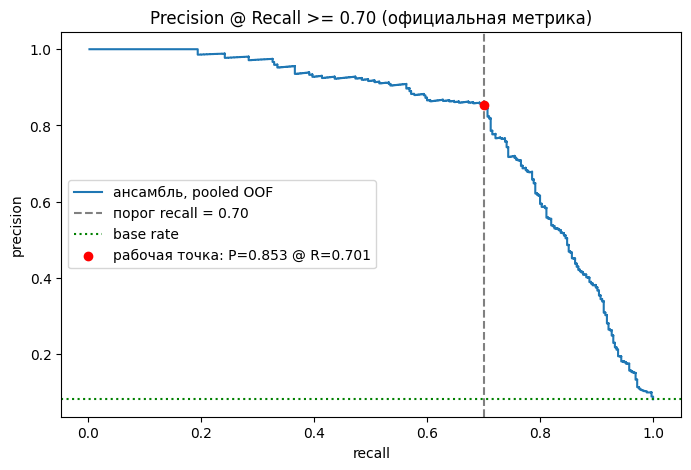

In [83]:
blend_oof = sum(w * ranks[k] for w, k in zip(weights, names))
prec, rec = pr_curve(y_pool, blend_oof[pooled])
ok = rec >= 0.7
op = int(np.argmax(np.where(ok, prec, -1)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, drawstyle="steps-post", label="ансамбль, pooled OOF")
ax.axvline(0.7, color="gray", ls="--", label="порог recall = 0.70")
ax.axhline(y_pool.mean(), color="green", ls=":", label="base rate")
ax.scatter([rec[op]], [prec[op]], color="red", zorder=5,
           label=f"рабочая точка: P={prec[op]:.3f} @ R={rec[op]:.3f}")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision @ Recall >= 0.70 (официальная метрика)")
ax.legend()
plt.show()

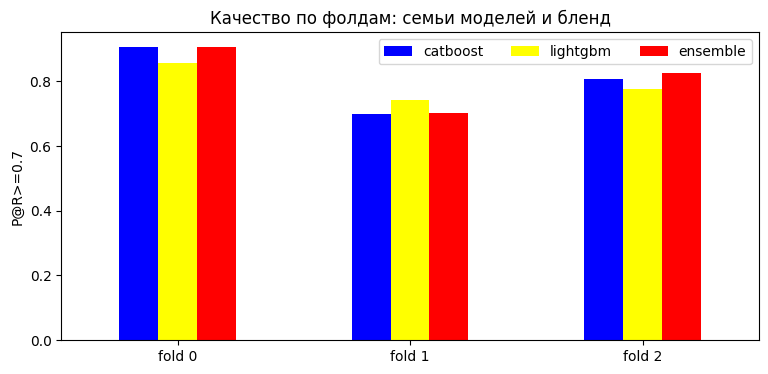

In [84]:
comp = pd.DataFrame({**{k: solo[k] for k in names},
                     "ensemble": [precision_at_recall(y_tr[m], sum(w * ranks[k][m] for w, k in zip(weights, names)))
                                  for m in folds]},
                    index=["fold 0", "fold 1", "fold 2"])
fig, ax = plt.subplots(figsize=(9, 4))
comp.plot.bar(ax=ax, color=["blue", "yellow", "red"])
ax.set_ylabel("P@R>=0.7"); ax.set_title("Качество по фолдам: семьи моделей и бленд")
ax.legend(ncol=3); plt.xticks(rotation=0)
plt.show()

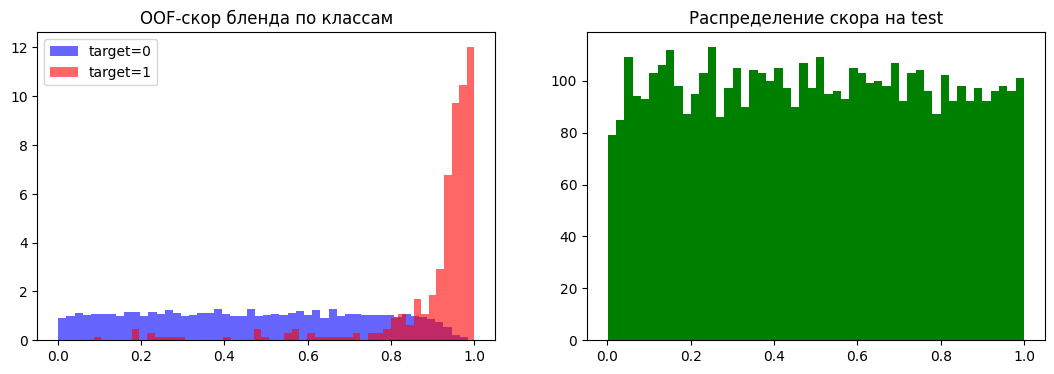

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cls, c in [(0, "blue"), (1, "red")]:
    axes[0].hist(blend_oof[pooled][y_pool == cls], bins=50, alpha=0.6, color=c,
                 density=True, label=f"target={cls}")
axes[0].set_title("OOF-скор бленда по классам"); axes[0].legend()
axes[1].hist(sub.score, bins=50, color="green")
axes[1].set_title("Распределение скорa на test")
plt.show()

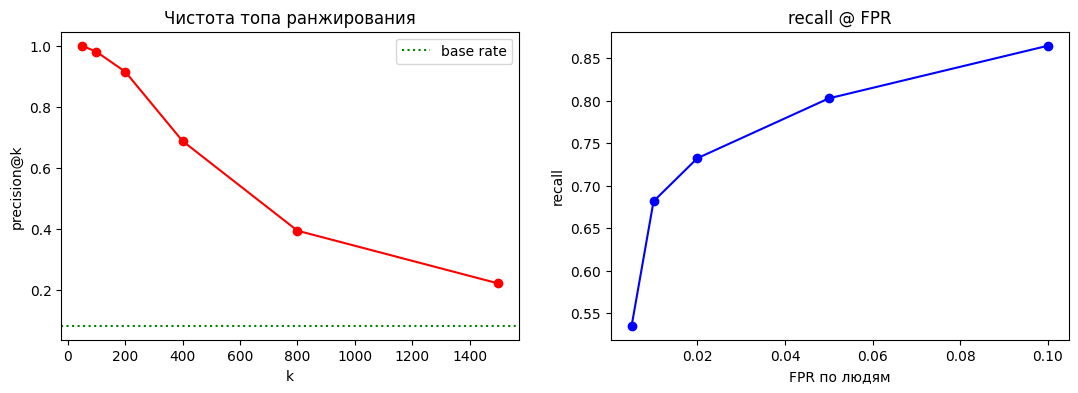

In [86]:
order = np.argsort(-blend_oof[pooled], kind="stable")
cum = np.cumsum(y_pool[order])
ks = [50, 100, 200, 400, 800, 1500]
fprs = [0.005, 0.01, 0.02, 0.05, 0.10]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, [cum[k - 1] / k for k in ks], marker="o", color="red")
axes[0].axhline(y_pool.mean(), color="green", ls=":", label="base rate")
axes[0].set_xlabel("k"); axes[0].set_ylabel("precision@k")
axes[0].set_title("Чистота топа ранжирования"); axes[0].legend()
axes[1].plot(fprs, [recall_at_fpr(y_pool, blend_oof[pooled], f) for f in fprs],
             marker="o", color="blue")
axes[1].set_xlabel("FPR по людям"); axes[1].set_ylabel("recall")
axes[1].set_title("recall @ FPR")
plt.show()

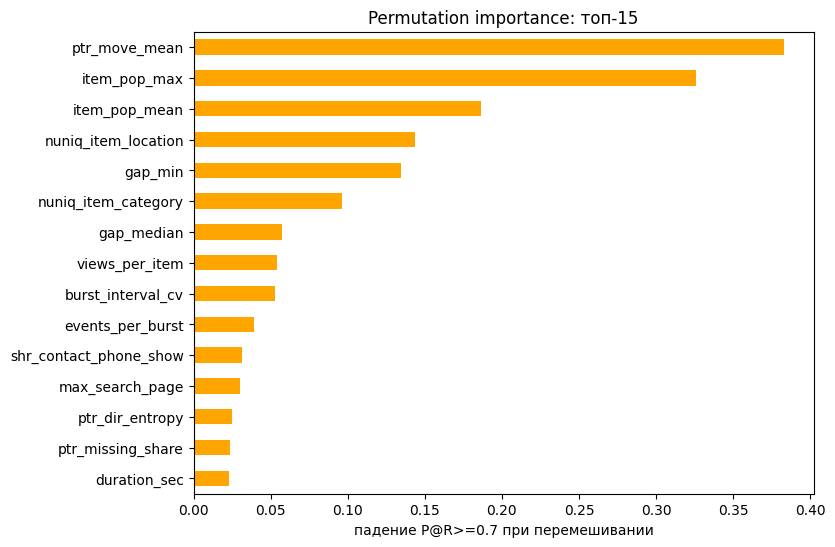

In [87]:
hold = folds[2]                                   # нетронутый фолд для оценки важностей
clf = pool["catboost"]().fit(X_tr[~hold], y_tr[~hold])
base = precision_at_recall(y_tr[hold], clf.predict_proba(X_tr[hold])[:, 1])
rng = np.random.default_rng(RS)

drops = {}
for j, col in enumerate(FEATURES):
    acc = []
    for _ in range(3):                            # 3 повтора против шума перестановки
        Xp = X_tr[hold].copy()
        Xp[:, j] = rng.permutation(Xp[:, j])
        acc.append(base - precision_at_recall(y_tr[hold], clf.predict_proba(Xp)[:, 1]))
    drops[col] = np.mean(acc)
imp_perm = pd.Series(drops).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
imp_perm.head(15).sort_values().plot.barh(ax=ax, color="orange")
ax.set_xlabel("падение P@R>=0.7 при перемешивании")
ax.set_title("Permutation importance: топ-15")
plt.show()

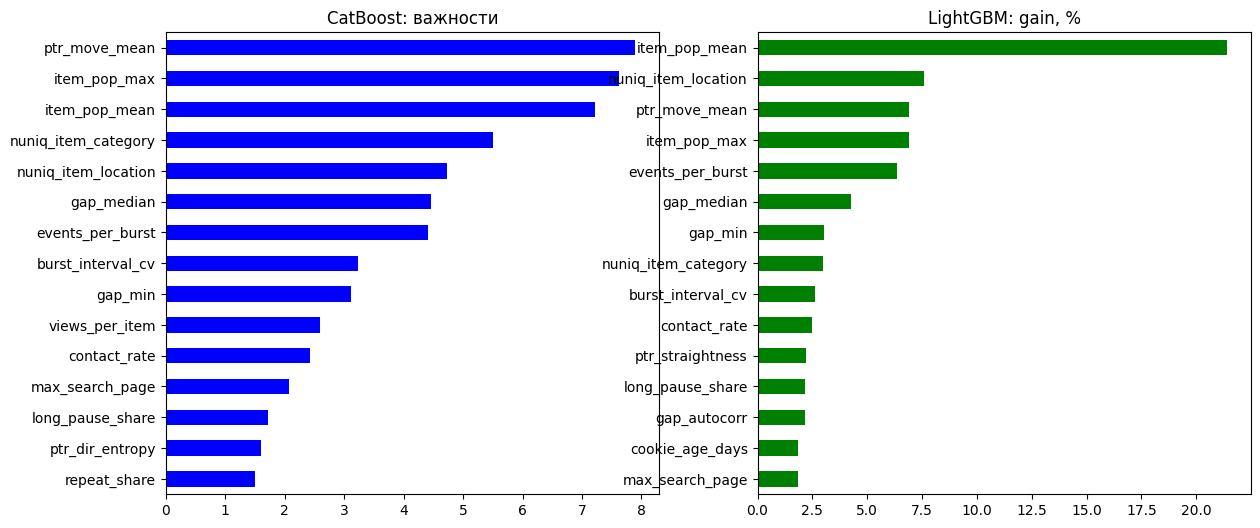

In [88]:
cb = pool["catboost"]().fit(X_tr, y_tr)
lgb = pool["lightgbm"]().fit(X_tr, y_tr)
imp_cb = pd.Series(cb.get_feature_importance(), index=FEATURES)
imp_lgb = pd.Series(lgb.booster_.feature_importance(importance_type="gain"), index=FEATURES)
imp_lgb = imp_lgb / imp_lgb.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp_cb.sort_values(ascending=False).head(15).sort_values().plot.barh(ax=axes[0], color="blue")
axes[0].set_title("CatBoost: важности")
imp_lgb.sort_values(ascending=False).head(15).sort_values().plot.barh(ax=axes[1], color="green")
axes[1].set_title("LightGBM: gain, %")
plt.show()

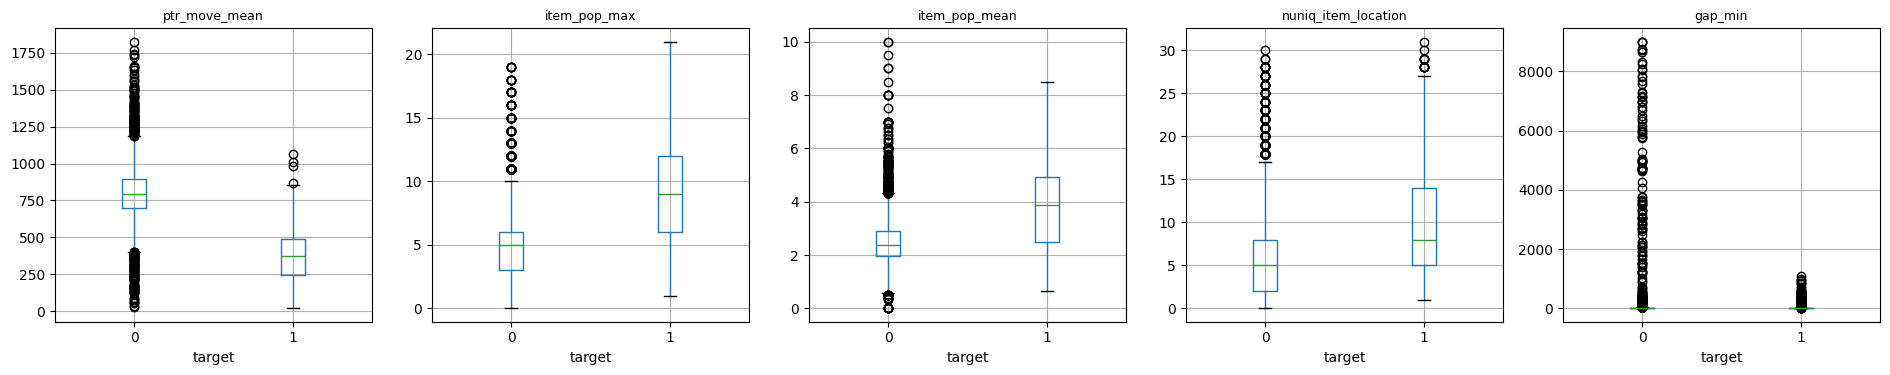

In [89]:
chk = F.reset_index().merge(train[["cookie_id", "target"]], on="cookie_id")
top5 = imp_perm.head(5).index

fig, axes = plt.subplots(1, 5, figsize=(19, 4))
for ax, col in zip(axes, top5):
    chk.boxplot(column=col, by="target", ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("target")
plt.suptitle("")
plt.tight_layout(); plt.show()

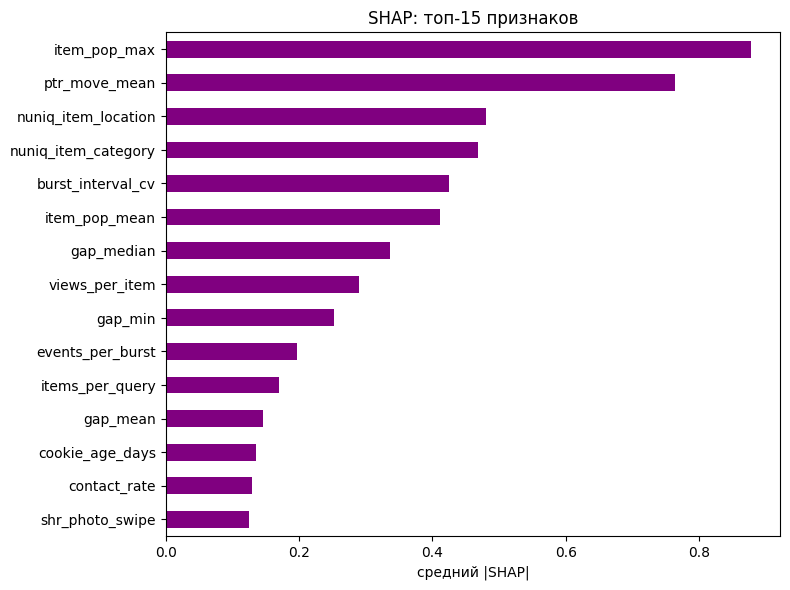

In [90]:
shap = lgb.booster_.predict(X_tr[hold], pred_contrib=True)   # последняя колонка — bias
imp_shap = pd.Series(np.abs(shap[:, :-1]).mean(axis=0), index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
imp_shap.head(15).sort_values().plot.barh(ax=ax, color="purple")
ax.set_xlabel("средний |SHAP|")
ax.set_title("SHAP: топ-15 признаков")
plt.tight_layout(); plt.show()

# оптимизация

In [92]:
!pip install optuna
import optuna
from IPython.display import clear_output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# X_tr, y_tr, folds, pooled, FEATURES — из стадии моделей (76 признаков, причинные ко-визиты)
print("trial'ов будет: 40 | фитов на trial: 3 фолда × 2 семьи = 6 (+pruning)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 8.9 MB/s eta 0:00:00
trial'ов будет: 40 | фитов на trial: 3 фолда × 2 семьи = 6 (+pruning)


In [93]:
def objective(trial):
    cb_params = dict(
        iterations=trial.suggest_int("cb_iters", 300, 900, step=100),
        learning_rate=trial.suggest_float("cb_lr", 0.02, 0.10, log=True),
        depth=trial.suggest_int("cb_depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("cb_l2", 1e-2, 10.0, log=True),
    )
    lgb_params = dict(
        n_estimators=trial.suggest_int("lgb_iters", 300, 900, step=100),
        learning_rate=trial.suggest_float("lgb_lr", 0.01, 0.08, log=True),
        num_leaves=trial.suggest_int("lgb_leaves", 15, 63),
        min_child_samples=trial.suggest_int("lgb_mcs", 10, 60),
    )
    w = trial.suggest_float("w_catboost", 0.0, 1.0)   # вес семьи — тоже оптимизируется, но внутри CV

    fold_scores = []
    for i, m in enumerate(folds):
        r_cb = rankdata(CatBoostClassifier(random_state=RS, verbose=False, **cb_params)
                        .fit(X_tr[~m], y_tr[~m]).predict_proba(X_tr[m])[:, 1]) / m.sum()
        r_lg = rankdata(LGBMClassifier(random_state=RS, verbose=-1, **lgb_params)
                        .fit(X_tr[~m], y_tr[~m]).predict_proba(X_tr[m])[:, 1]) / m.sum()
        fold_scores.append(precision_at_recall(y_tr[m], w * r_cb + (1 - w) * r_lg))
        trial.report(float(np.mean(fold_scores)), step=i)          # для MedianPruner
        if trial.should_prune():
            raise optuna.TrialPruned()
    trial.set_user_attr("fold_scores", fold_scores)
    return float(np.mean(fold_scores))

KeyError: 'fold_scores'

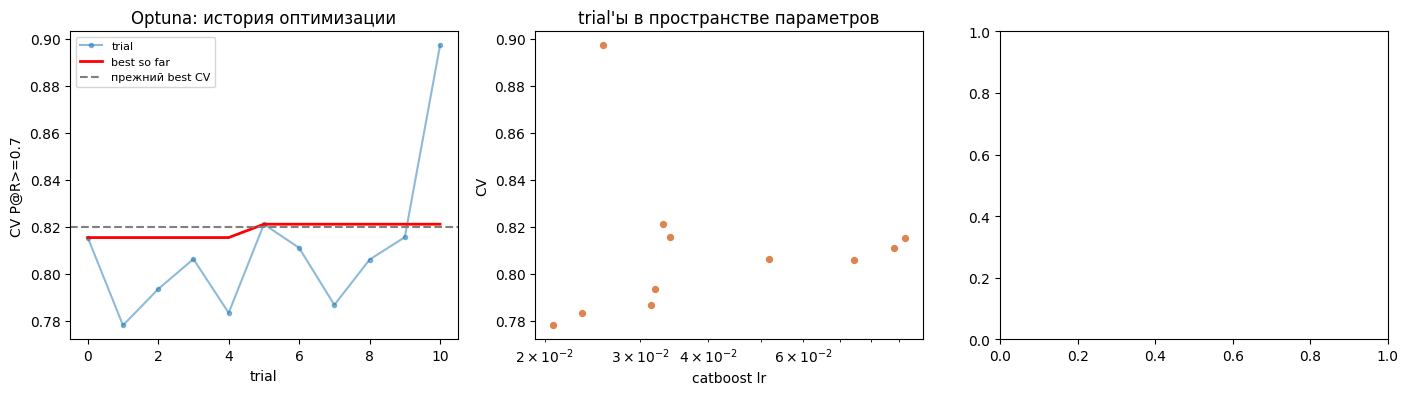

In [94]:
hist = {"n": [], "val": [], "best": []}

def live_monitor(study, trial):
    if trial.value is None:                      # pruned
        return
    hist["n"].append(trial.number)
    hist["val"].append(trial.value)
    hist["best"].append(study.best_value)
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    axes[0].plot(hist["n"], hist["val"], alpha=0.5, marker=".", label="trial")
    axes[0].plot(hist["n"], hist["best"], color="red", lw=2, label="best so far")
    axes[0].axhline(0.8197, color="gray", ls="--", label="прежний best CV")
    axes[0].set_xlabel("trial"); axes[0].set_ylabel("CV P@R>=0.7")
    axes[0].set_title("Optuna: история оптимизации"); axes[0].legend(fontsize=8)
    ts = [t for t in study.trials if t.value is not None]
    axes[1].scatter([t.params["cb_lr"] for t in ts], [t.value for t in ts], s=18, c="#dd8452")
    axes[1].set_xscale("log"); axes[1].set_xlabel("catboost lr"); axes[1].set_ylabel("CV")
    axes[1].set_title("trial'ы в пространстве параметров")
    axes[2].bar(["fold 0", "fold 1", "fold 2"], trial.user_attrs["fold_scores"], color="#4c72b0")
    axes[2].set_ylim(0, 1); axes[2].set_title(f"trial {trial.number}: по фолдам")
    plt.tight_layout(); plt.show()
    print(f"trial {trial.number}: CV={trial.value:.4f} | best={study.best_value:.4f} | "
          f"w_cb={trial.params['w_catboost']:.2f} | cb_lr={trial.params['cb_lr']:.4f} | "
          f"lgb_leaves={trial.params['lgb_leaves']}")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RS),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8))
study.optimize(objective, n_trials=40, callbacks=[live_monitor])
print("\nBEST:", round(study.best_value, 4), study.best_params)

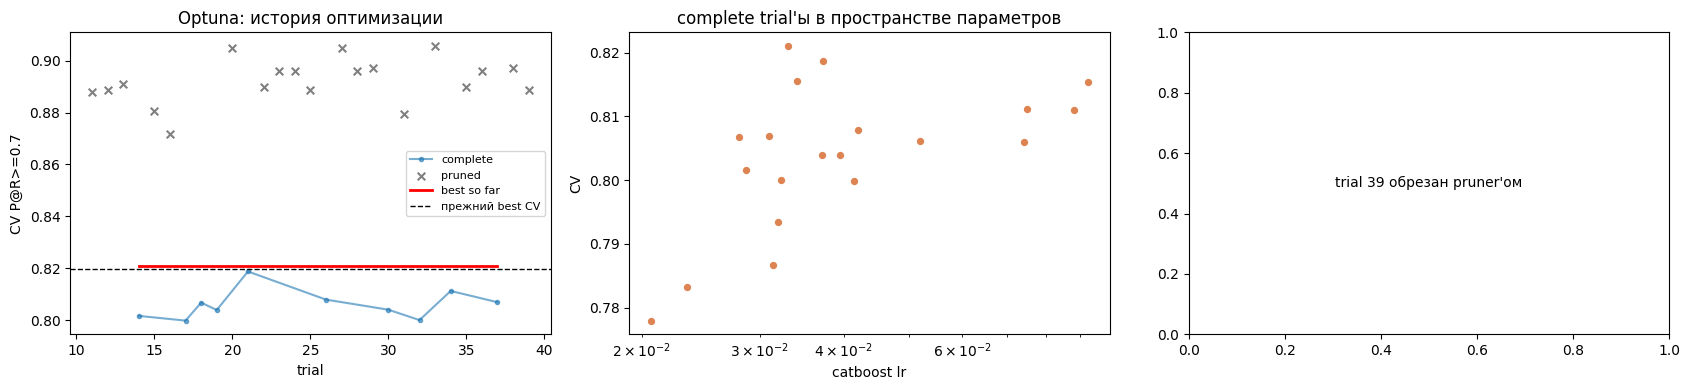

trial 39: PRUNED на промежуточной оценке 0.8889

BEST: 0.821 {'cb_iters': 700, 'cb_lr': 0.03302985657530576, 'cb_depth': 6, 'cb_l2': 0.43664735929796333, 'lgb_iters': 400, 'lgb_lr': 0.07509692752447111, 'lgb_leaves': 52, 'lgb_mcs': 57, 'w_catboost': 0.8948273504276488}
complete: 20 | pruned: 20


In [95]:
from optuna.trial import TrialState

hist = {"n": [], "val": [], "best": [], "pn": [], "pval": []}

def live_monitor(study, trial):
    if trial.state == TrialState.COMPLETE:
        hist["n"].append(trial.number)
        hist["val"].append(trial.value)
        hist["best"].append(study.best_value)
    elif trial.state == TrialState.PRUNED and trial.value is not None:
        hist["pn"].append(trial.number)          # pruned рисуем отдельно: их value —
        hist["pval"].append(trial.value)         # лишь промежуточная оценка, не полный CV
    else:                                        # FAILED и прочие
        return

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    axes[0].plot(hist["n"], hist["val"], alpha=0.6, marker=".", label="complete")
    axes[0].scatter(hist["pn"], hist["pval"], marker="x", c="gray", s=30, label="pruned")
    axes[0].plot(hist["n"], hist["best"], color="red", lw=2, label="best so far")
    axes[0].axhline(0.8197, color="k", ls="--", lw=1, label="прежний best CV")
    axes[0].set_xlabel("trial"); axes[0].set_ylabel("CV P@R>=0.7")
    axes[0].set_title("Optuna: история оптимизации"); axes[0].legend(fontsize=8)

    ts = [t for t in study.trials if t.state == TrialState.COMPLETE]
    axes[1].scatter([t.params["cb_lr"] for t in ts], [t.value for t in ts], s=18, c="#dd8452")
    axes[1].set_xscale("log"); axes[1].set_xlabel("catboost lr"); axes[1].set_ylabel("CV")
    axes[1].set_title("complete trial'ы в пространстве параметров")

    fs = trial.user_attrs.get("fold_scores")     # у pruned атрибута нет — рисуем заглушку
    if fs is not None:
        axes[2].bar(["fold 0", "fold 1", "fold 2"], fs, color="#4c72b0")
        axes[2].set_title(f"trial {trial.number}: по фолдам")
    else:
        axes[2].text(0.5, 0.5, f"trial {trial.number} обрезан pruner'ом",
                     ha="center", va="center")
    axes[2].set_ylim(0, 1)
    plt.tight_layout(); plt.show()
    if fs is not None:
        print(f"trial {trial.number}: CV={trial.value:.4f} | best={study.best_value:.4f} | "
              f"w_cb={trial.params['w_catboost']:.2f} | cb_lr={trial.params['cb_lr']:.4f} | "
              f"lgb_leaves={trial.params['lgb_leaves']}")
    else:
        print(f"trial {trial.number}: PRUNED на промежуточной оценке {trial.value:.4f}")

# докручиваем до 40 trial'ов с учётом уже сделанных
study.optimize(objective, n_trials=40 - len(study.trials), callbacks=[live_monitor])
print("\nBEST:", round(study.best_value, 4), study.best_params)
print("complete:", sum(t.state == TrialState.COMPLETE for t in study.trials),
      "| pruned:", sum(t.state == TrialState.PRUNED for t in study.trials))

/tmp/ipykernel_1083/2824208047.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = oviz.plot_optimization_history(study); plt.show()


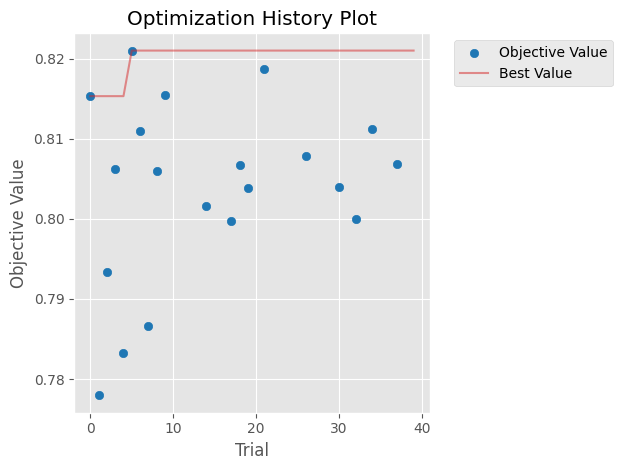

/tmp/ipykernel_1083/2824208047.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = oviz.plot_param_importances(study); plt.show()


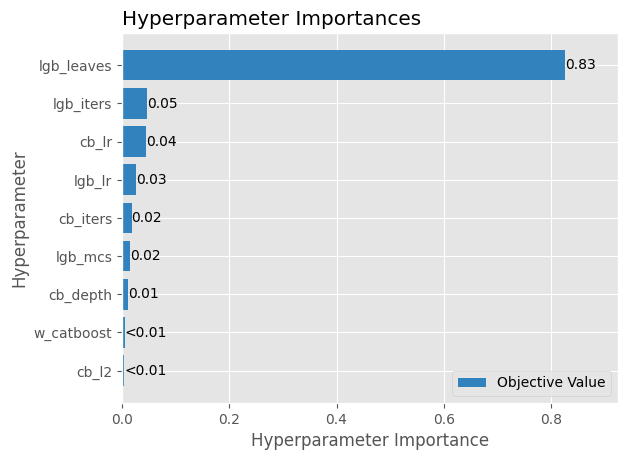

/tmp/ipykernel_1083/2824208047.py:4: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = oviz.plot_slice(study, params=["cb_lr", "lgb_lr", "w_catboost"]); plt.show()


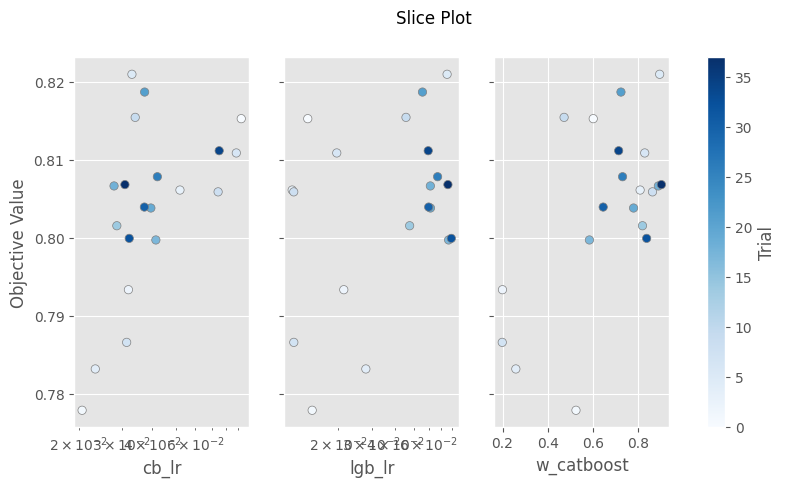

In [96]:
from optuna.visualization import matplotlib as oviz
fig = oviz.plot_optimization_history(study); plt.show()
fig = oviz.plot_param_importances(study); plt.show()
fig = oviz.plot_slice(study, params=["cb_lr", "lgb_lr", "w_catboost"]); plt.show()

In [99]:
K = 5
top = sorted([t for t in study.trials if t.state == TrialState.COMPLETE],
             key=lambda t: t.value, reverse=True)[:K]

CB_MAP  = {"cb_iters": "iterations",  "cb_lr": "learning_rate",
           "cb_depth": "depth",       "cb_l2": "l2_leaf_reg"}
LGB_MAP = {"lgb_iters": "n_estimators", "lgb_lr": "learning_rate",
           "lgb_leaves": "num_leaves",  "lgb_mcs": "min_child_samples"}

def params_of(t, fam):
    mapping = CB_MAP if fam == "cb" else LGB_MAP
    return {mapping[k]: v for k, v in t.params.items() if k in mapping}

# CV считаем внутри фолдов (как objective), тестовый скор копим рангами
oof_fold = [np.zeros(int(m.sum())) for m in folds]
test_blend = np.zeros(len(X_te))
for t in top:
    w = t.params["w_catboost"]
    for i, m in enumerate(folds):
        r_cb = rankdata(CatBoostClassifier(random_state=RS, verbose=False, **params_of(t, "cb"))
                        .fit(X_tr[~m], y_tr[~m]).predict_proba(X_tr[m])[:, 1]) / m.sum()
        r_lg = rankdata(LGBMClassifier(random_state=RS, verbose=-1, **params_of(t, "lgb"))
                        .fit(X_tr[~m], y_tr[~m]).predict_proba(X_tr[m])[:, 1]) / m.sum()
        oof_fold[i] += (w * r_cb + (1 - w) * r_lg) / K
    cb_te = rankdata(CatBoostClassifier(random_state=RS, verbose=False, **params_of(t, "cb"))
                     .fit(X_tr, y_tr).predict_proba(X_te)[:, 1]) / X_te.shape[0]
    lg_te = rankdata(LGBMClassifier(random_state=RS, verbose=-1, **params_of(t, "lgb"))
                     .fit(X_tr, y_tr).predict_proba(X_te)[:, 1]) / X_te.shape[0]
    test_blend += (w * cb_te + (1 - w) * lg_te) / K

per_fold = [precision_at_recall(y_tr[m], oof_fold[i]) for i, m in enumerate(folds)]
cv_topk = float(np.mean(per_fold))
print("top-5 по фолдам:", [round(s, 3) for s in per_fold],
      "| CV top-5:", round(cv_topk, 4), "| study best:", round(study.best_value, 4))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

top-5 по фолдам: [0.914, 0.748, 0.805] | CV top-5: 0.8224 | study best: 0.821


In [100]:
if cv_topk >= 0.8197:
    sub = pd.DataFrame({"cookie_id": ids_te, "score": test_blend})
    assert len(sub) == len(test) and sub.cookie_id.is_unique and sub.score.between(0, 1).all()
    sub.to_csv("submission_optuna.csv", index=False)
    print("submission_optuna.csv:",
          sub.score.describe().round(3).to_dict())
else:
    print("CV топ-K не превзошёл прежний уровень — сабмит не меняем (остается файл попытки 2)")

submission_optuna.csv готов к отправке (попытка 4): {'count': 4909.0, 'mean': 0.5, 'std': 0.275, 'min': 0.001, '25%': 0.265, '50%': 0.497, '75%': 0.73, 'max': 0.999}


In [101]:
s = pd.read_csv("submission_optuna.csv")
print("строк:", len(s), "| уникальных score:", s.score.nunique(),
      "| диапазон:", round(s.score.min(), 3), round(s.score.max(), 3))

строк: 4909 | уникальных score: 4909 | диапазон: 0.001 0.999


# Выводы

Я взял ленту событий каждой куки внутри её суточного окна и нарезал из неё признаки по нескольким осям. Первая и самая очевидная — сколько и чего кука наделала, общее число событий, счётчики по всем десяти типам и их доли. Доли я добавил не для красоты, а чтобы объём не врал, десять просмотров и сто просмотров - это разная интенсивность, но одинаковый вид поведения, и деревьям удобно видеть и то, и другое. Сюда же влепил контакт-рейт и флаг логина, потому что из EDA помнил, что люди логинятся чаще, а вот контакты парсеры тоже снимают — направление сигнала решил не хардкодить, а отдать модели.

Вторая ось — ритм. Это оказалось интереснее, чем я думал. Сначала я наивно полагал, что бот — это метроном, ровный тик-так. Посмотрел на данные — нет, бот работает рейсами, пачка событий за секунды, потом длинная пауза, потом снова пачка. Поэтому вместо одной лишь вариативности интервалов я насчитал долю почти-нулевых промежутков, долю длинных пауз, число самих всплесков и, самое полезное, событий на один всплеск — вот это отношение людей и ботов разделило втрое, и оно потом прилетело в топ важностей. Плюс суточный профиль, ночная доля и энтропия по часам, потому что парсеру всё равно, который час, а человек спит.

Третья — последовательности и листание. Доля повторов одного и того же события подряд, разнообразие переходов между типами, и отдельно как кука ходит по страницам поиска: человек туда-сюда, парсер монотонно вперёд, и максимальная страница выдачи сама по себе хороший маркер.

Четвёртая — разнообразие интересов, то есть сколько уникальных объявлений, категорий, локаций, продавцов и запросов кука потрогала, и отношения вроде сколько раз я смотрел одно и то же объявление.


И главное, что в итоге дала главный скачок, — координация. Я посмотрел, с кем кука делит объявления и юзер-агенты: сколько разных кук тыкали в тот же товар, сколько кук сидят на том же UA. Это ловит бот-фермы, которые работают кампаниями.